# AI Level Design Triage Agent

An advisory multi agent workflow that triages a single 2D platformer level candidate against a designer's natural language brief. Given a brief and a candidate level, the system interprets intent, gathers facts with deterministic tools, reasons about the tradeoffs, and recommends the next design action.

This notebook is an executable demonstration and experiment harness. The product is the Python package in `src/`; the notebook runs it, shows the agent behavior, compares models, and evaluates the workflow across scenarios.

## Notebook Purpose and System Summary

- Three agents do the judgment: an Intent Interpreter, a Triage Director (optimizer, ReAct; Yao et al., 2022), and a Critic (evaluator), in a bounded evaluator-optimizer loop. Three agents are used rather than one because a single agent cannot both propose a recommendation and independently evaluate its own recommendation without bias, so intent interpretation, the decision, and the evaluation stay in distinct roles.
- The Triage Director calls deterministic tools for facts (tool calling; Schick et al., 2023); a thin safety floor enforces hard safety; the agents decide and explain.
- The terminal action is one of: accept for playtest, recommend revision (with a prescription), request clarification, flag as derivative draft, reject for structural reasons, or request human review.

## Setup and Imports

This section imports the system package from `src/`, loads the API credentials and the model identifier from `.env`, sets the random seed for reproducibility, and enables inline plotting, so the rest of the notebook can run the agent.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nest_asyncio
from dotenv import load_dotenv
from IPython.display import Markdown

# Load OPENAI_API_KEY and TRIAGE_MODEL from .env (override stale OS values).
load_dotenv(override=True)

# Pydantic AI run_sync uses an event loop; Jupyter already runs one, so allow nesting.
nest_asyncio.apply()

from src.models import TriageRequest
from src.level_io import load_level
from src.scenarios import load_scenarios, build_triage_request, acceptable_actions
from src.reference_library import load_reference_levels
from src.tools import TOOL_REGISTRY
from src.agents import DEFAULT_MODEL
from src.model_config import EXPERIMENT_MODELS, GPT_4_1, estimate_cost
from src.workflow import triage_candidate, run_scenario_suite, save_audit_log, append_run_log
from src.report import generate_report, save_transcript
from src.evals import run_eval_suite

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("default model:", DEFAULT_MODEL)

c:\Users\bjm20\Documents\Udacity AI MBA\Capstone\agentic-ai-level-design-triage-agent\src\agents.py:56: PydanticAIDeprecationWarning: `Agent(output_retries=...)` is deprecated and will be removed in v2.0. Use `retries={'output': ...}` (or `retries=<int>` to set the same budget for both tool and output retries) instead.
  intent_interpreter = Agent(
c:\Users\bjm20\Documents\Udacity AI MBA\Capstone\agentic-ai-level-design-triage-agent\src\agents.py:96: PydanticAIDeprecationWarning: `Agent(output_retries=...)` is deprecated and will be removed in v2.0. Use `retries={'output': ...}` (or `retries=<int>` to set the same budget for both tool and output retries) instead.
  triage_director = Agent(
c:\Users\bjm20\Documents\Udacity AI MBA\Capstone\agentic-ai-level-design-triage-agent\src\agents.py:203: PydanticAIDeprecationWarning: `Agent(output_retries=...)` is deprecated and will be removed in v2.0. Use `retries={'output': ...}` (or `retries=<int>` to set the same budget for both tool and outp

default model: openai-chat:gpt-4.1


In [2]:
%matplotlib inline

## Design Briefs and Candidate Loading

This section loads the seven evaluation scenarios (each a natural language brief paired with a candidate level and an expected behavior) and the hand authored reference library that the novelty tool measures similarity against.

In [3]:
scenarios = load_scenarios()
reference_levels = load_reference_levels()
print(f"{len(scenarios)} scenarios, {len(reference_levels)} reference levels")

pd.DataFrame([
    {"id": s.scenario_id, "name": s.name, "brief": s.brief_text,
     "expected": s.expected_action, "acceptable": ", ".join(sorted(acceptable_actions(s)))}
    for s in scenarios
])

7 scenarios, 10 reference levels


,id,name,brief,expected,acceptable
0,S1,Beginner excitement tradeoff,I want a beginner friendly first level that st...,recommend_revision,recommend_revision
1,S2,Style consistency vs originality,Make this level feel consistent with my existi...,flag_as_derivative_draft,"flag_as_derivative_draft, recommend_revision"
2,S3,Conflicting brief,I want this to be easy and welcoming for brand...,request_clarification,"request_clarification, request_human_review"
3,S4,Playtest readiness,Is this beginner level ready for a first playt...,accept_for_playtest,accept_for_playtest
4,S5,Structural defect,Get this segment ready for playtest as a norma...,reject_structural,reject_structural
5,S6,"Preserve layout, reduce frustration",Reduce the frustration in this level but prese...,recommend_revision,recommend_revision
6,S7,Ambiguous brief,Make this good. I am not totally sure what I w...,request_clarification,"request_clarification, request_human_review"


## State Schema and Tool Registry

This section lists the six deterministic tools the Triage Director can call, which report facts only and never decide, and prints a sample candidate level so the tile format is visible before the agent runs.

In [4]:
# The deterministic tools the Triage Director calls. They report facts only.
pd.DataFrame(TOOL_REGISTRY)

,tool,purpose
0,validate_candidate_level,"Check structure, vocabulary, dimensions, and p..."
1,estimate_candidate_difficulty,"Estimate heuristic, structural difficulty"
2,measure_candidate_novelty,Measure similarity and derivative risk vs the ...
3,analyze_candidate_pacing,Describe challenge pacing across the segment
4,detect_candidate_safe_zone,Check for an opening safe zone for beginners
5,detect_candidate_spike,Find a localized low leniency difficulty spike


In [5]:
# A sample candidate level (the S4 clean beginner level).
print(build_triage_request({s.scenario_id: s for s in scenarios}["S4"]).candidate_level)

--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
------ooo-----------------------
--------------------<>----------
--------------------[]----------
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX


## Single Scenario Walkthrough

One scenario run end to end, showing the agentic flow: the interpreted intent, the tools the Director chose to call, the decision and readiness, the evaluator-optimizer rounds, and token usage. This walkthrough uses `gpt-4.1` for a clean demonstration; the model actually chosen for the system is decided by the experiment in the next section.

In [6]:
scenario = {s.scenario_id: s for s in scenarios}["S1"]
request = build_triage_request(scenario)
walkthrough = triage_candidate(
    request, reference_levels, model=GPT_4_1.model, model_settings=GPT_4_1.settings
)

print("Scenario:", scenario.scenario_id, "-", scenario.name)
print("Brief:", scenario.brief_text)
print("Model:", GPT_4_1.label)
print("\nInterpreted intent:")
for key, value in walkthrough.intent.model_dump().items():
    print(f"  {key}: {value}")
print("\nTools the Director called, in order:")
for entry in walkthrough.tool_call_log:
    print("  -", entry.tool_name)
print("\nDecision:", walkthrough.decision,
      "| readiness:", walkthrough.recommendation.playtest_readiness,
      "| rounds:", walkthrough.round_count)
print("Critic verdict:", walkthrough.critique.verdict)
u = walkthrough.token_usage
print(f"Tokens: {u.input_tokens} in / {u.output_tokens} out ({u.requests} requests)")

Scenario: S1 - Beginner excitement tradeoff
Brief: I want a beginner friendly first level that still feels a little exciting. Keep the opening approachable for brand new players.
Model: gpt-4.1

Interpreted intent:
  target_audience: beginner
  desired_feel: ['exciting', 'approachable']
  difficulty_target: easy
  novelty_preference: medium
  hard_constraints: []
  soft_preferences: ['beginner friendly', 'exciting opening']
  detected_conflicts: []

Tools the Director called, in order:
  - validate_candidate_level
  - estimate_candidate_difficulty
  - measure_candidate_novelty
  - analyze_candidate_pacing
  - detect_candidate_safe_zone
  - detect_candidate_spike

Decision: recommend_revision | readiness: revise_before_playtest | rounds: 1
Critic verdict: approve
Tokens: 5322 in / 516 out (4 requests)


In [7]:
Markdown(generate_report(walkthrough))

# AI Level Design Triage Report

## Design Brief
I want a beginner friendly first level that still feels a little exciting. Keep the opening approachable for brand new players.

## Interpreted Intent
- Target audience: beginner
- Difficulty target: easy
- Novelty preference: medium
- Desired feel: exciting, approachable
- Hard constraints: (none)
- Soft preferences: beginner friendly, exciting opening
- Detected conflicts: (none)

## Triage Decision
- Action: recommend_revision
- Playtest readiness: revise_before_playtest
- Confidence: high
- Rounds: 1

## Diagnosis
The level is structurally valid and matches the easy difficulty target, but it lacks an opening safe zone, placing the first enemy challenge at column 3. For a beginner-friendly, approachable segment, this is too abrupt and may frustrate new players. The pacing is otherwise balanced, and novelty is within the desired medium range.

## Tradeoff Reasoning
- The absence of an opening safe zone conflicts with the intent for a beginner-friendly, approachable experience, as new players need a short stretch to orient before encountering hazards.
- The easy difficulty and balanced pacing otherwise align with the brief, and the medium novelty is appropriate.

## Revision Prescription
- Move the first enemy (E) further right to at least column 6 or later, creating a short safe stretch at the start of the level. (This gives beginners time to orient themselves before facing a challenge, supporting the approachable and beginner-friendly intent.)

Playtest question: After moving the enemy, does the opening feel welcoming and give new players enough time to get comfortable before the first challenge?

## Independent Critic
- Verdict: approve
The Director's recommendation is sound. The diagnosis correctly identifies that the absence of an opening safe zone is inconsistent with the intent for a beginner-friendly, approachable segment. The prescription to move the first enemy further right is appropriate and directly addresses the issue without overreaching. All other aspects of the level (difficulty, novelty, pacing, structural validity) are consistent with the brief. No hard constraints are violated, and the recommendation does not under- or over-reach.

## Factual Appendix (deterministic)
### Measured facts
- Valid: True
- Difficulty: easy (score 0.223, longest gap 0)
- Novelty: medium (nearest neighbour similarity 0.9014)
- Pacing: balanced (opening 1, middle 0, final 0)
- Safe zone: False (first challenge column 3)
- Difficulty spike: False
### Tool call log
- validate_candidate_level
- estimate_candidate_difficulty
- measure_candidate_novelty
- analyze_candidate_pacing
- detect_candidate_safe_zone
- detect_candidate_spike
### Candidate level
```text
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
----------o---------------------
--------------------------------
---E----------------------------
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
```

## Limitations
- Difficulty is heuristic and structural, not player validated.
- This system is advisory. It never edits the level; the designer makes every change.
- The human designer makes the final decision.


## Model Selection Experiment

We choose the model before tuning, so the tuning targets the model we will actually ship. Each candidate model ran the full scenario suite on the **same untuned prompts**, so the comparison measures how well each model handles the task out of the box.

- **Models:** `gpt-4o-mini` (cheap floor), `gpt-4.1` (general), `gpt-5.1` (frontier reasoning).
- **Metrics:** acceptable-action match rate, average evaluator-optimizer rounds (convergence), token usage, and estimated cost.
- **Repeats:** each scenario was run 3 times per model, because outputs vary even at temperature 0.

This comparison was run once on the untuned prompts and saved to `outputs/eval_results/model_comparison.csv` as a frozen baseline. The cell below **loads** those saved results rather than regenerating them, because the agents have since been tuned and a fresh run would no longer be the untuned baseline. To reproduce the sweep from scratch you would set PROMPT_VARIANT=baseline (the untuned prompts are kept in prompt_templates/baseline/) and delete the CSV (3 models x 7 scenarios x 3 repeats = 63 live passes, a few dollars).

In [8]:
COMPARISON_CSV = Path("outputs/eval_results/model_comparison.csv")

# Frozen untuned baseline: load the saved results rather than regenerate, because the
# agents have since been tuned. To reproduce the untuned sweep, set
# PROMPT_VARIANT=baseline (the baseline prompts are kept in prompt_templates/baseline/)
# and delete the CSV.
if COMPARISON_CSV.exists():
    comparison_df = pd.read_csv(COMPARISON_CSV)
    print(f"Loaded the saved untuned model comparison: {len(comparison_df)} passes.")
else:
    COMPARISON_CSV.parent.mkdir(parents=True, exist_ok=True)
    REPEATS = 3
    total = len(EXPERIMENT_MODELS) * REPEATS * len(scenarios)
    rows = []
    running_cost = 0.0
    done = 0
    for config in EXPERIMENT_MODELS:
        for repeat in range(1, REPEATS + 1):
            for scenario in scenarios:
                done += 1
                state = triage_candidate(
                    build_triage_request(scenario), reference_levels,
                    model=config.model, model_settings=config.settings,
                )
                usage = state.token_usage
                rec = state.recommendation
                cost = estimate_cost(usage.input_tokens, usage.output_tokens, config)
                running_cost += cost
                prescription = ""
                if rec.prescription is not None:
                    prescription = "; ".join(
                        f"{edit.description} ({edit.reason})" for edit in rec.prescription.suggested_edits
                    )
                rows.append({
                    "model": config.label,
                    "repeat": repeat,
                    "scenario": scenario.scenario_id,
                    "decision": state.decision,
                    "match": state.decision in acceptable_actions(scenario),
                    "rounds": state.round_count,
                    "input_tokens": usage.input_tokens,
                    "output_tokens": usage.output_tokens,
                    "cost_usd": cost,
                    "diagnosis": rec.diagnosis,
                    "tradeoff_reasoning": " | ".join(rec.tradeoff_reasoning),
                    "prescription": prescription,
                    "critic_verdict": state.critique.verdict if state.critique else "",
                    "critic_assessment": state.critique.assessment if state.critique else "",
                })
                pd.DataFrame(rows).to_csv(COMPARISON_CSV, index=False)
                print(f"[{done:>2}/{total}] {config.label:<12} {scenario.scenario_id} rep{repeat} "
                      f"-> {state.decision:<22} {state.round_count}r  (${running_cost:.3f} so far)", flush=True)
    comparison_df = pd.DataFrame(rows)
    print(f"\nDone: {len(comparison_df)} passes; saved to {COMPARISON_CSV}")

comparison_df.head()

Loaded the saved untuned model comparison: 63 passes.


,model,repeat,scenario,decision,match,rounds,input_tokens,output_tokens,cost_usd,diagnosis,tradeoff_reasoning,prescription,critic_verdict,critic_assessment
0,gpt-4o-mini,1,S1,request_human_review,False,5,33098,2240,0.006309,"The segment lacks an opening safe zone, which ...",The target audience is beginners who need time...,Add a safe zone of 2-3 rows at the beginning o...,revise,The recommendation correctly identifies the ab...
1,gpt-4o-mini,1,S2,request_human_review,False,5,24615,2393,0.005128,"The candidate level is rated as easy, which co...",The designer aims for a medium difficulty leve...,Increase enemy density by adding more enemies ...,revise,The recommendation to increase enemy density a...
2,gpt-4o-mini,1,S3,request_human_review,True,5,25109,2673,0.005370,The candidate level presents a medium difficul...,The overall difficulty is too high for a begin...,Reduce the gap size at the first challenge to ...,revise,The recommendation correctly identifies the co...
3,gpt-4o-mini,1,S4,request_human_review,False,1,386,62,0.000095,A model round exceeded the per-run request bud...,NaN,NaN,NaN,NaN
4,gpt-4o-mini,1,S5,reject_structural,True,1,4878,349,0.000941,"The candidate level has structural issues, spe...",The level must be structurally sound to ensure...,NaN,approve,The recommendation to reject the candidate lev...


In [9]:
comparison_df = pd.read_csv(COMPARISON_CSV)
summary = (
    comparison_df.groupby("model")
    .agg(
        match_rate=("match", "mean"),
        avg_rounds=("rounds", "mean"),
        avg_input_tokens=("input_tokens", "mean"),
        avg_output_tokens=("output_tokens", "mean"),
        total_cost_usd=("cost_usd", "sum"),
    )
    .reindex([config.label for config in EXPERIMENT_MODELS])
)
summary.round(3)

,match_rate,avg_rounds,avg_input_tokens,avg_output_tokens,total_cost_usd
model,,,,,
gpt-4o-mini,0.429,3.667,20079.286,1763.905,0.085
gpt-4.1,0.571,1.000,5090.048,535.238,0.304
gpt-5.1,0.524,1.000,5601.333,1026.905,0.363


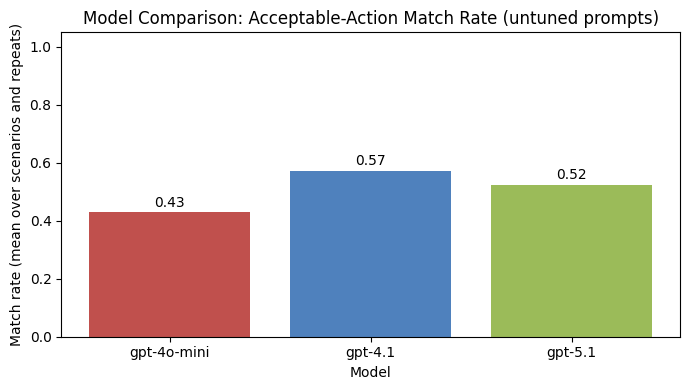

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary.index, summary["match_rate"], color=["#c0504d", "#4f81bd", "#9bbb59"])
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison: Acceptable-Action Match Rate (untuned prompts)")
ax.set_xlabel("Model")
ax.set_ylabel("Match rate (mean over scenarios and repeats)")
for index, value in enumerate(summary["match_rate"]):
    ax.text(index, value + 0.02, f"{value:.2f}", ha="center")
fig.tight_layout()
Path("outputs/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("outputs/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The chart shows gpt-4.1 with the highest acceptable action match rate on the untuned prompts, ahead of gpt-5.1 and gpt-4o-mini. The gpt-4o-mini bar is misleadingly high: it escalates almost everything to human review, so it only matches where escalation happens to be acceptable, as the per scenario view below makes clear.

## Per Scenario Comparison

The aggregate match rate hides where the models actually differ. This matrix shows
the most common decision per model per scenario, with the acceptable-action match
fraction in parentheses.

In [11]:
comparison_df = pd.read_csv(COMPARISON_CSV)

records = []
for (scenario_id, model_label), group in comparison_df.groupby(["scenario", "model"]):
    decision = group["decision"].mode().iloc[0]
    records.append({
        "scenario": scenario_id,
        "model": model_label,
        "result": f"{decision} ({group['match'].mean():.0%})",
    })
matrix = pd.DataFrame(records).pivot(index="scenario", columns="model", values="result")
matrix = matrix.reindex(columns=[config.label for config in EXPERIMENT_MODELS])
matrix

model,gpt-4o-mini,gpt-4.1,gpt-5.1
scenario,,,
S1,request_human_review (0%),recommend_revision (100%),recommend_revision (100%)
S2,request_human_review (0%),flag_as_derivative_draft (100%),flag_as_derivative_draft (67%)
S3,request_human_review (100%),recommend_revision (0%),recommend_revision (0%)
S4,request_human_review (0%),accept_for_playtest (100%),accept_for_playtest (100%)
S5,reject_structural (100%),reject_structural (100%),reject_structural (100%)
S6,request_human_review (0%),accept_for_playtest (0%),accept_for_playtest (0%)
S7,request_human_review (100%),recommend_revision (0%),accept_for_playtest (0%)


## Commentary Comparison

On a judgment task the reasoning matters as much as the action. For a given
scenario this shows each model's diagnosis, tradeoff reasoning, prescription, and
the critic's assessment side by side. Change the scenario id to inspect any case
(S2 derivative, S3 conflicting, S6 frustration, S7 ambiguous are the revealing
ones).

In [12]:
comparison_df = pd.read_csv(COMPARISON_CSV)


def show_commentary(scenario_id, repeat=1):
    """Print each model's reasoning for one scenario, side by side."""
    subset = comparison_df[(comparison_df.scenario == scenario_id) & (comparison_df.repeat == repeat)]
    print(f"=== {scenario_id} commentary (repeat {repeat}) ===")
    for _, row in subset.iterrows():
        print(f"\n--- {row['model']} -> {row['decision']} ---")
        print("Diagnosis:", row["diagnosis"])
        print("Tradeoff:", row["tradeoff_reasoning"])
        if isinstance(row["prescription"], str) and row["prescription"]:
            print("Prescription:", row["prescription"])
        print(f"Critic ({row['critic_verdict']}):", row["critic_assessment"])


show_commentary("S2")

=== S2 commentary (repeat 1) ===

--- gpt-4o-mini -> request_human_review ---
Diagnosis: The candidate level is rated as easy, which conflicts with the medium difficulty target specified in the design intent.
Tradeoff: The designer aims for a medium difficulty level, but the current candidate is rated as easy, which does not meet this target. | Increasing enemy density and introducing additional hazards can raise the difficulty without compromising the core layout, but this must be done carefully to maintain familiarity and consistency.
Prescription: Increase enemy density by adding more enemies in the middle section of the level. (This will raise the overall difficulty while still allowing the core layout to remain intact.); Introduce additional hazards, such as moving platforms or spikes, in the middle section of the level. (This will create more challenge without altering the core layout, aligning with the medium difficulty target.)
Critic (revise): The recommendation to increase en

## Model Selection and Conclusion

Across the three models on the same untuned prompts:

- **gpt-4.1 is the strongest choice.** It reaches the highest acceptable action match rate (about 0.57), converges in a single evaluator-optimizer round, and costs less than gpt-5.1. It genuinely decides the clear cases (the beginner safe zone fix, the derivative flag, the clean accept, the structural reject) rather than defaulting.
- **gpt-4o-mini is not viable.** Its headline match rate (about 0.43) is misleading: it escalates almost everything to request_human_review and fails to converge (about 3.7 rounds), so it only matches the scenarios where escalation happens to be acceptable. It is right for the wrong reason.
- **gpt-5.1 underperforms out of the box (about 0.52).** It over-accepts, accepting the ambiguous brief (S7) and the frustration case (S6) and revising the conflicting brief (S3) instead of asking for clarification, and it costs the most (more reasoning and output tokens). It does flag the derivative case (S2) most of the time, so its weakness is conflict and ambiguity handling, not derivative detection. A stronger model is not automatically better on this task without tuning.

The per scenario view exposes two genuine weaknesses shared by the capable models, which become the tuning targets:

- **S3 and S7:** neither detects a conflicting (S3) or ambiguous (S7) brief; they revise or accept instead of requesting clarification. The intent interpreter and the director need to surface and act on brief conflicts and ambiguity.
- **S6:** both capable models accept, because the fixture's mild frustration is not captured by any deterministic fact (the spike detector needs a wider gap). This is a fixture limitation, addressed by strengthening the candidate, not by prompt tuning.

**Decision: adopt gpt-4.1 as the triage model**, then tune it for the S3 and S7 clarification gap and strengthen the S6 fixture. The system stays model agnostic via TRIAGE_MODEL, so the frontier reasoning models can be revisited after tuning.

## Tuning Validation

After selecting gpt-4.1, the Intent Interpreter and Triage Director were tuned for the two weaknesses the comparison exposed: the interpreter now surfaces conflicting (S3) and ambiguous (S7) briefs into `detected_conflicts`, and the director requests clarification when the brief is conflicting or ambiguous rather than acting on a guessed target. The S6 candidate was also strengthened to a detectable difficulty spike.

This section re-runs the tuned gpt-4.1 on the scenarios and compares it to the untuned gpt-4.1 baseline from the model comparison above. Restart the kernel before running so the tuned `src` modules are loaded.

These are the same seven scenarios that informed the tuning targets, so this is an in-sample confirmation that tuning resolved the intended behaviors, not a held out generalization test.

In [13]:
TUNING_CSV = Path("outputs/eval_results/tuning_validation.csv")

tuned_rows = []
for scenario in scenarios:
    state = triage_candidate(
        build_triage_request(scenario), reference_levels,
        model=GPT_4_1.model, model_settings=GPT_4_1.settings,
    )
    matched = state.decision in acceptable_actions(scenario)
    tuned_rows.append({
        "scenario": scenario.scenario_id,
        "expected": scenario.expected_action,
        "tuned_decision": state.decision,
        "match": matched,
        "rounds": state.round_count,
    })
    print(f"{scenario.scenario_id}: {state.decision:<22} match={matched}", flush=True)

tuned_df = pd.DataFrame(tuned_rows)
TUNING_CSV.parent.mkdir(parents=True, exist_ok=True)
tuned_df.to_csv(TUNING_CSV, index=False)
print(f"\nTuned gpt-4.1 match rate: {tuned_df['match'].mean():.2f}")
tuned_df

S1: recommend_revision     match=True
S2: flag_as_derivative_draft match=True
S3: request_clarification  match=True
S4: accept_for_playtest    match=True
S5: reject_structural      match=True
S6: recommend_revision     match=True
S7: request_clarification  match=True

Tuned gpt-4.1 match rate: 1.00


,scenario,expected,tuned_decision,match,rounds
0,S1,recommend_revision,recommend_revision,True,1
1,S2,flag_as_derivative_draft,flag_as_derivative_draft,True,1
2,S3,request_clarification,request_clarification,True,1
3,S4,accept_for_playtest,accept_for_playtest,True,1
4,S5,reject_structural,reject_structural,True,1
5,S6,recommend_revision,recommend_revision,True,1
6,S7,request_clarification,request_clarification,True,1


In [14]:
model_comparison = pd.read_csv("outputs/eval_results/model_comparison.csv")
untuned = (
    model_comparison[model_comparison.model == "gpt-4.1"]
    .groupby("scenario")["decision"].agg(lambda s: s.mode().iloc[0])
)
tuned = pd.read_csv("outputs/eval_results/tuning_validation.csv").set_index("scenario")
before_after = pd.DataFrame({
    "expected": tuned["expected"],
    "untuned_gpt_4_1": untuned,
    "tuned_gpt_4_1": tuned["tuned_decision"],
    "tuned_match": tuned["match"],
}).reindex([f"S{i}" for i in range(1, 8)])
before_after

,expected,untuned_gpt_4_1,tuned_gpt_4_1,tuned_match
scenario,,,,
S1,recommend_revision,recommend_revision,recommend_revision,True
S2,flag_as_derivative_draft,flag_as_derivative_draft,flag_as_derivative_draft,True
S3,request_clarification,recommend_revision,request_clarification,True
S4,accept_for_playtest,accept_for_playtest,accept_for_playtest,True
S5,reject_structural,reject_structural,reject_structural,True
S6,recommend_revision,accept_for_playtest,recommend_revision,True
S7,request_clarification,recommend_revision,request_clarification,True


## Tuning Diagnostic (S3 and S7)

S3 (conflicting) and S7 (ambiguous) were the two cases the untuned model got wrong, resolving to recommend_revision instead of request_clarification. This cell traces the fix: for each, it shows what the Intent Interpreter put in `detected_conflicts` and how the Director reasoned. With the tuned prompts the interpreter now surfaces the conflict and the vagueness, and the Director acts on `detected_conflicts` by requesting clarification rather than guessing a target.

In [15]:
for sid in ["S3", "S7"]:
    sc = {s.scenario_id: s for s in scenarios}[sid]
    state = triage_candidate(
        build_triage_request(sc), reference_levels,
        model=GPT_4_1.model, model_settings=GPT_4_1.settings,
    )
    print(f"===== {sid}: {sc.brief_text}")
    print("detected_conflicts:", state.intent.detected_conflicts)
    print("difficulty_target:", state.intent.difficulty_target, "| audience:", state.intent.target_audience)
    print("decision:", state.decision)
    print("diagnosis:", state.recommendation.diagnosis)
    print("tradeoff:", " | ".join(state.recommendation.tradeoff_reasoning))
    print()

===== S3: I want this to be easy and welcoming for brand new players, but also pack in lots of enemies and big gaps so it feels intense and hardcore.
detected_conflicts: ['Beginner accessibility and easy difficulty conflict with the request for lots of enemies, big gaps, and an intense/hardcore feel.']
difficulty_target: easy | audience: beginner
decision: request_clarification
diagnosis: The interpreted intent contains a detected conflict: the brief requests a beginner-friendly, easy segment that is also intense and hardcore, with lots of enemies and big gaps. These requirements are at odds, as intensity, many enemies, and large gaps typically raise difficulty and reduce accessibility for beginners. This ambiguity makes it unclear which aspect should take priority in the design.
tradeoff: The candidate is structurally valid and has a safe opening, which is good for beginners. | However, the presence of a localized difficulty spike (gap combined with enemy at column 9) and a medium dif

## Full Scenario Evaluation Suite

The tuned system (gpt-4.1) run across every scenario. For each scenario this saves a triage report to `outputs/reports/`, an audit log and a readable transcript to `outputs/logs/`, and appends a line to the running log `outputs/logs/triage_runs.jsonl`, alongside a results summary in `outputs/scenario_results.csv`. `match_expected` scores against the acceptable action set for each scenario.

In [20]:
suite_results = run_scenario_suite(scenarios, reference_levels)
print("Reports -> outputs/reports/, logs -> outputs/logs/, summary -> outputs/scenario_results.csv")
pd.DataFrame([r.model_dump() for r in suite_results])[
    ["scenario_id", "name", "expected_action", "actual_action", "readiness", "match_expected", "rounds"]
]

Reports -> outputs/reports/, logs -> outputs/logs/, summary -> outputs/scenario_results.csv


,scenario_id,name,expected_action,actual_action,readiness,match_expected,rounds
0,S1,Beginner excitement tradeoff,recommend_revision,recommend_revision,revise_before_playtest,True,1
1,S2,Style consistency vs originality,flag_as_derivative_draft,flag_as_derivative_draft,ready_for_playtest,True,1
2,S3,Conflicting brief,request_clarification,request_clarification,not_ready,True,1
3,S4,Playtest readiness,accept_for_playtest,accept_for_playtest,ready_for_playtest,True,1
4,S5,Structural defect,reject_structural,reject_structural,not_ready,True,1
5,S6,"Preserve layout, reduce frustration",recommend_revision,recommend_revision,revise_before_playtest,True,1
6,S7,Ambiguous brief,request_clarification,request_clarification,revise_before_playtest,True,1


## Evaluation Suite

Because the agent makes judgments, the eval suite asserts invariants and required properties rather than exact action equality: action and readiness are valid and consistent, the safety invariants hold (an invalid candidate is never accepted or ready, a revision recommendation carries a prescription), and the recommendation is complete. Exact agreement with each scenario's expected action is reported as a score, not asserted.

In [21]:
report = run_eval_suite(reference_levels)
averages = report.averages()
print(f"invariant assertions passing: {averages.assertions:.0%}")
for name, score in averages.scores.items():
    print(f"score {name}: {score:.3f}")

Output()

invariant assertions passing: 100%
score ExpectedActionMatch: 1.000


## Results Summary and Output Reports

One saved triage report, rendered. Each report is the agents' narrative (diagnosis, tradeoff reasoning, prescription, critic assessment) plus a deterministic factual appendix, so the numbers are ground truth.

In [18]:
Markdown(Path("outputs/reports/S1.md").read_text(encoding="utf-8"))

# AI Level Design Triage Report

## Design Brief
I want a beginner friendly first level that still feels a little exciting. Keep the opening approachable for brand new players.

## Interpreted Intent
- Target audience: beginner
- Difficulty target: easy
- Novelty preference: medium
- Desired feel: exciting, approachable
- Hard constraints: (none)
- Soft preferences: beginner friendly, exciting feel, approachable opening
- Detected conflicts: (none)

## Triage Decision
- Action: recommend_revision
- Playtest readiness: revise_before_playtest
- Confidence: high
- Rounds: 1

## Diagnosis
The level is structurally valid and matches the easy difficulty target, but it lacks an opening safe zone for beginners. The first enemy appears at column 3, which is too abrupt for a beginner-friendly segment. The pacing is otherwise balanced, and novelty is within the desired range.

## Tradeoff Reasoning
- The absence of an opening safe zone conflicts with the intent for an approachable, beginner-friendly level. Beginners need a short stretch to orient before encountering hazards.
- The easy difficulty and balanced pacing otherwise fit the brief, and the novelty is appropriate.

## Revision Prescription
- Move the first enemy (E) further right, so that the first hazard appears no earlier than column 6. (This creates a short safe stretch at the start, giving beginners time to orient and making the opening more approachable.)

Playtest question: Does the new opening feel approachable and give beginners enough time to get oriented before the first challenge?

## Independent Critic
- Verdict: approve
The Director's recommendation is sound. The diagnosis correctly identifies that the absence of an opening safe zone is inconsistent with the intent for a beginner-friendly, approachable level. The prescription to move the first enemy further right to create a safe stretch is appropriate and directly addresses the issue. All other aspects of the level (difficulty, novelty, pacing, structural validity) are consistent with the brief. There are no hard constraint violations, and the recommendation does not overreach or underreach. The action is justified and well-targeted.

## Factual Appendix (deterministic)
### Measured facts
- Valid: True
- Difficulty: easy (score 0.223, longest gap 0)
- Novelty: medium (nearest neighbour similarity 0.9014)
- Pacing: balanced (opening 1, middle 0, final 0)
- Safe zone: False (first challenge column 3)
- Difficulty spike: False
### Tool call log
- validate_candidate_level
- estimate_candidate_difficulty
- measure_candidate_novelty
- analyze_candidate_pacing
- detect_candidate_safe_zone
- detect_candidate_spike
### Candidate level
```text
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
----------o---------------------
--------------------------------
---E----------------------------
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
```

## Limitations
- Difficulty is heuristic and structural, not player validated.
- This system is advisory. It never edits the level; the designer makes every change.
- The human designer makes the final decision.


## Safeguards, Limitations, and Final Notes

| Risk | System response |
|---|---|
| Structurally invalid candidate | The validation tool flags it; the safety floor never lets it be accepted or called ready |
| Conflicting or ambiguous brief | The interpreter flags it in detected_conflicts; the director requests clarification rather than guessing a target |
| Low novelty / derivative content | Flagged as a derivative draft; not shipped as final without variation |
| Heuristic difficulty | Disclosed as structural and not player validated in every report |
| Agent over-reach | The independent critic can dispute; the loop is bounded; an unresolved dispute escalates to human review |
| Automation vs creative control | The agent never edits the level; it advises, and the designer makes every change |

These safeguards follow established guidance for human and AI interaction, which emphasizes keeping the user in control and making the system's reasoning transparent (Amershi et al., 2019).

Limitations: difficulty is a structural heuristic, not player validated; the reference library is a small hand authored set, so derivative detection is relative to it; and LLM reasoning is non deterministic, which is why evaluation relies on invariants and scenario behavior rather than exact action matching.

## Try It Yourself: Live Demonstration

A final end to end run of the system on a single request, the way a designer would actually use it: provide a natural language brief and one candidate level, and receive a triage decision, a designer facing report, and a full audit transcript. This run uses an ad hoc brief, not one of the evaluation scenarios, to show the agent handling arbitrary input.

The code cell below runs the agent live and renders its report. It also writes the same artifacts the terminal command produces: an audit log (`outputs/logs/demo.json`), a readable transcript (`outputs/logs/demo_transcript.md`), and an appended line in the running log (`outputs/logs/triage_runs.jsonl`).

Run it from the terminal instead:

```bash
# A built in evaluation fixture
python scripts/run_triage.py --scenario S1

# Your own brief and candidate level
python scripts/run_triage.py --brief "A short, punchy level for confident players" --candidate data/candidate_levels/candidate_s4_playtest_ready.txt
```

The terminal runner prints the report and writes the same audit log, transcript, and running log line, so the system logs every run whether it is launched from the notebook or the command line.

In [19]:
# Final live demonstration: run the agent on one ad hoc request, show its outputs, and
# write the same artifacts the terminal runner produces.
demo_brief = "A short, punchy level for confident players. Ramp up quickly but keep it fair."
demo_candidate = load_level("data/candidate_levels/candidate_s4_playtest_ready.txt")
demo_request = TriageRequest(brief_text=demo_brief, candidate_level=demo_candidate)

demo_session = triage_candidate(
    demo_request, reference_levels, model=GPT_4_1.model, model_settings=GPT_4_1.settings
)

save_audit_log(demo_session, "outputs/logs/demo.json")
save_transcript(demo_session, "outputs/logs/demo_transcript.md")
append_run_log(demo_session)

u = demo_session.token_usage
print("Decision:", demo_session.decision, "| readiness:", demo_session.recommendation.playtest_readiness)
print("Rounds:", demo_session.round_count, "| critic:", demo_session.critique.verdict)
print(f"Tokens: {u.input_tokens} in / {u.output_tokens} out ({u.requests} requests)")
print("\nTranscript (what each agent did, in order):")
for e in demo_session.transcript:
    tag = e.agent if e.round is None else f"{e.agent} r{e.round}"
    extra = f"  {e.tool_name}" if e.tool_name else ""
    print(f"  [{e.step:>2}] {e.role:<9} {tag}{extra}")

Markdown(generate_report(demo_session))

Decision: recommend_revision | readiness: revise_before_playtest
Rounds: 1 | critic: approve
Tokens: 5466 in / 659 out (4 requests)

Transcript (what each agent did, in order):
  [ 1] system    workflow
  [ 2] user      intent_interpreter
  [ 3] assistant intent_interpreter  final_result
  [ 4] tool      intent_interpreter  final_result
  [ 5] assistant intent_interpreter
  [ 6] user      triage_director r1
  [ 7] assistant triage_director r1  check_validity
  [ 8] assistant triage_director r1  check_difficulty
  [ 9] assistant triage_director r1  check_novelty
  [10] assistant triage_director r1  check_pacing
  [11] assistant triage_director r1  check_safe_zone
  [12] assistant triage_director r1  check_spike
  [13] tool      triage_director r1  check_validity
  [14] tool      triage_director r1  check_difficulty
  [15] tool      triage_director r1  check_novelty
  [16] tool      triage_director r1  check_pacing
  [17] tool      triage_director r1  check_safe_zone
  [18] tool      tri

# AI Level Design Triage Report

## Design Brief
A short, punchy level for confident players. Ramp up quickly but keep it fair.

## Interpreted Intent
- Target audience: intermediate
- Difficulty target: medium
- Novelty preference: medium
- Desired feel: punchy, exciting
- Hard constraints: (none)
- Soft preferences: quick difficulty ramp, fair challenge
- Detected conflicts: (none)

## Triage Decision
- Action: recommend_revision
- Playtest readiness: revise_before_playtest
- Confidence: high
- Rounds: 1

## Diagnosis
The candidate is structurally valid and has medium novelty, but its difficulty is rated as 'easy' with no hazards or enemies present, and the pacing is completely flat. This does not meet the intent for a 'medium' difficulty, 'punchy' and 'exciting' segment for intermediate players. The level lacks any challenge or ramp, and does not deliver the desired feel.

## Tradeoff Reasoning
- The level is structurally sound and safe for playtest, but it does not align with the intended difficulty or excitement.
- The absence of hazards, enemies, or challenge elements means the segment is not punchy or exciting, and does not provide a quick difficulty ramp as requested.

## Revision Prescription
- Add hazards (such as pits, enemies, or moving obstacles) starting after a short safe opening, ramping up in frequency or complexity toward the end of the segment. (This will create a quick difficulty ramp and introduce fair challenge, matching the 'medium' difficulty and 'exciting' feel desired for intermediate players.)
- Introduce at least one layered challenge (e.g., a gap with an enemy above it or a moving platform with a hazard nearby) in the latter half of the segment. (Layered hazards increase excitement and punchiness, and are appropriate for intermediate, medium-difficulty segments.)
- Use coins or visual cues to guide the player through new or tricky jumps, especially where hazards are introduced. (Guidance helps maintain fairness and supports the 'fair challenge' preference.)

Playtest question: Does the revised segment deliver a punchy, exciting challenge that ramps up quickly and feels fair for intermediate players?

## Independent Critic
- Verdict: approve
The Director's recommendation is sound. The candidate level is structurally valid and has medium novelty, but it is rated as 'easy' with no hazards, enemies, or challenge elements, and the pacing is completely flat. This does not align with the intent for a 'medium' difficulty, 'punchy', and 'exciting' segment for intermediate players. The prescribed edits directly address the lack of challenge and excitement, and the recommendation does not overreach or underreach. No hard constraints are violated, and the diagnosis is consistent with the facts and intent.

## Factual Appendix (deterministic)
### Measured facts
- Valid: True
- Difficulty: easy (score 0.0, longest gap 0)
- Novelty: medium (nearest neighbour similarity 0.9167)
- Pacing: flat (opening 0, middle 0, final 0)
- Safe zone: True (first challenge column 32)
- Difficulty spike: False
### Tool call log
- validate_candidate_level
- measure_candidate_novelty
- estimate_candidate_difficulty
- analyze_candidate_pacing
- detect_candidate_safe_zone
- detect_candidate_spike
### Candidate level
```text
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
--------------------------------
------ooo-----------------------
--------------------<>----------
--------------------[]----------
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
```

## Limitations
- Difficulty is heuristic and structural, not player validated.
- This system is advisory. It never edits the level; the designer makes every change.
- The human designer makes the final decision.


## Summary

The AI Level Design Triage Agent is an advisory, multi agent workflow that triages one 2D platformer level candidate against a natural language design brief. Three Pydantic AI agents do the judgment: an Intent Interpreter converts the brief into a structured intent and flags conflicts and vagueness, a Triage Director gathers facts with deterministic tools and chooses one of six actions, and an independent Critic evaluates the recommendation in a bounded evaluator-optimizer loop, while a thin deterministic safety floor enforces hard safety. Across the seven scenarios the system interprets intent, recommends next actions with concrete revision prescriptions, flags derivative content, asks for clarification on conflicting or ambiguous briefs, and rejects structurally invalid candidates, always leaving the edit to the designer. A model comparison selected gpt-4.1 over gpt-4o-mini and gpt-5.1. The key challenge was that neither capable model reliably detected conflicting or ambiguous briefs without tuning, which required targeted revision to the Intent Interpreter and Triage Director prompts to reach full agreement with the intended actions. Known limitations include heuristic (not player validated) difficulty, a small hand authored reference library, and the non determinism of LLM reasoning, which is why evaluation relies on invariants and scenario behavior rather than exact action matching. The agent never replaces the designer; it surfaces evidence and a recommended next step and preserves creative control.

## References

Amershi, S., Weld, D., Vorvoreanu, M., Fourney, A., Nushi, B., Collisson, P., Suh, J., Iqbal, S., Bennett, P. N., Inkpen, K., Teevan, J., Kikin-Gil, R., & Horvitz, E. (2019). Guidelines for human-AI interaction. *Proceedings of the 2019 CHI Conference on Human Factors in Computing Systems.* https://doi.org/10.1145/3290605.3300233

Schick, T., Dwivedi-Yu, J., Dessì, R., Raileanu, R., Lomeli, M., Zettlemoyer, L., Cancedda, N., & Scialom, T. (2023). *Toolformer: Language models can teach themselves to use tools.* arXiv:2302.04761. https://arxiv.org/abs/2302.04761

Yao, S., Zhao, J., Yu, D., Du, N., Shafran, I., Narasimhan, K., & Cao, Y. (2022). *ReAct: Synergizing reasoning and acting in language models.* arXiv:2210.03629. https://arxiv.org/abs/2210.03629